# Hope Cement Works — Amine Optimization & WHR Integration, Monte Carlo

Companion to `Hope_Amine_Optimization_Model.xlsx`. This supersedes the earlier oxy-fuel-vs-amine
comparison (kept separately as `Peak_Cluster_Feedstock_Derisking_Model.xlsx` / its notebook — still
valid as a benchmark case for sites with modern precalciners, e.g. Tarmac's Cauldon, but NOT for Hope).

**Why the change:** Breedon publicly confirmed (March 2025) that amine scrubbing — not oxy-fuel — is
"closest to realisation" for Hope, with a disclosed ~£400M capture capex. An EA permit decision document
separately confirms Hope's kilns are 1970s-vintage with a preheater but **no calciner**, which makes a
main-burner oxy-fuel retrofit a much harder, less-precedented job than the modern-precalciner literature
assumes. So instead of pitching a different capture technology, this model treats the £400M amine plant
as fixed and asks: what's the smallest capital add-on that meaningfully cuts its running cost?

**The add-on package:** (1) route kiln waste heat directly to the amine reboiler's steam demand instead
of converting it to electricity via an ORC turbine, (2) a De-SOx pretreatment step to protect the amine
solvent from Hope's unusually sulphur-rich local shale, (3) BESS to buffer the pipeline-compression load.

## 1. Fixed assumptions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 10_000

VOL = 1_200_000          # t CO2/yr (Hope Valley Climate Action)
CLINKER_TPY = 1_250_000  # estimated from 1.5Mt/yr cement capacity x ~0.85 clinker ratio
HOURS = 8000.0
CO2_REF = 0.20
CO2_BASE = 0.20
TARIFF_DEFAULT = 105.0
THERMAL_COST = 35.0
COMPR = 105.0
AMINE_ELEC = 40.0
AMINE_THERMAL = 900.0
AMINE_CAPEX_TPA = 333.0        # matches Breedon's disclosed ~£400M almost exactly
AMINE_OPEX_OPT = 8.0           # protected (with De-SOx pretreatment)
WHR_FRAC = 0.35
XFER_EFF = 0.85
BESS_CAPEX_KWH = 280.0
BESS_MW = 10.0
BESS_HRS = 4.0
GRID_OFFSET = 3_000_000.0
DISC = 0.08
LIFE = 20

CRF = (DISC * (1 + DISC) ** LIFE) / ((1 + DISC) ** LIFE - 1)
base_capex = AMINE_CAPEX_TPA * VOL
print(f"Base amine capex (shared by both cases): £{base_capex:,.0f}  — Breedon disclosed ~£400M")
print(f"CRF: {CRF:.4f}")


Base amine capex (shared by both cases): £399,600,000  — Breedon disclosed ~£400M
CRF: 0.1019


## 2. Uncertain inputs

(De-SOx protection opex P and degradation-risk opex D moved to Section 2b — coupled to a shared inlet-SOx driver rather than sampled independently; see that section for full sourcing.)

| Variable | Distribution | Rationale |
|---|---|---|
| Specific heat consumption | Uniform(3.3, 4.2) GJ/t clinker | Range for a 1970s preheater-only kiln (no calciner); drives kiln MWth and hence WHR supply |
| De-SOx pretreatment capex | Uniform(£10, £25)/tpa | No public benchmark — placeholder pending vendor quote |
| WHR thermal-integration capex | Uniform(£73.8k, £141.7k)/MWth | **CORRECTED**: de-annualized using the paper's own published assumptions (7.5% interest, 25yr lifetime, 8000 op-hrs/yr — the last one independently matches this model), then inflated 2016->2026 EUR terms via Eurostat HICP (+33.0% to 2025). Previous version of this line used an incorrectly assumed 8%/20yr rate. Their case studies (13-14 MWth) are still much smaller than Hope's ~58 MWth recoverable — untested scale extrapolation remains the main residual risk. |
| Grid electricity tariff | Normal(£105, £15), clipped [£85, £140] | DESNZ/Ofgem-informed large-industrial range |


**Update, Aug 2026 (v2):** the WHR thermal-integration capex range has now been corrected twice. First pass used the real Table B1/B2 cement case-study CAPEX data, but de-annualized it assuming an 8%/20yr discount rate that turned out not to match the paper. The paper's own assumptions table gives 7.5% interest / 25yr lifetime / 8000 op-hrs-yr (the last figure independently matches this model's own assumption). Re-deriving with the correct rate, and inflating 2016->2026 EUR terms via Eurostat HICP (+33.0% cumulative to 2025), gives a higher and more defensible range: £73.8k-£141.7k/MWth (was £47.8k-£91.8k). The De-SOx pretreatment capex line remains an unverified placeholder and is now the dominant source of remaining payback uncertainty.

In [2]:
spec_heat = rng.uniform(3.3, 4.2, N)
polisher_capex_tpa = rng.uniform(10, 25, N)  # RECLASSIFIED (was 'desox_capex_tpa', always-on placeholder).
                                               # This is now the magnitude IF a standalone SOx polisher/wet
                                               # FGD is needed -- a discrete downside scenario (Section 2b),
                                               # not a central-case add-on. See markdown for the reasoning.
whr_capex_per_mwth = rng.uniform(73_800, 141_700, N)  # CORRECTED — de-annualized using the paper's OWN 7.5%/25yr rate (not an assumed 8%/20yr), inflated 2016->2026 EUR (Eurostat HICP)
tariff = np.clip(rng.normal(105, 15, N), 85, 140)

print("Sampled ranges:")
for name, arr in [("Specific heat GJ/t", spec_heat),
                   ("Polisher capex £/tpa (downside scenario only)", polisher_capex_tpa), ("WHR capex £/MWth", whr_capex_per_mwth),
                   ("Tariff £/MWh", tariff)]:
    print(f"  {name:46s} min={arr.min():.2f}  mean={arr.mean():.2f}  max={arr.max():.2f}")


Sampled ranges:
  Specific heat GJ/t                             min=3.30  mean=3.75  max=4.20
  Polisher capex £/tpa (downside scenario only)  min=10.00  mean=17.54  max=25.00
  WHR capex £/MWth                               min=73803.21  mean=107918.51  max=141698.81
  Tariff £/MWh                                   min=85.00  mean=105.55  max=140.00


## 2b. De-SOx opex — coupled protection cost (P) and degradation risk (D)

**Update, Aug 2026 (v3):** the old `amine_opex_base = Uniform(£12,£15)/t` placeholder and the fixed
"+£1.5/t De-SOx opex" placeholder are both replaced below with a single coupled structure, built from
a real primary source: Hope Cement Works' EA Decision Document (2017, gov.uk, permit EPR/BP3731VJ).

**What the source gives us:**
- Confirmed actual 2017 operating SOx: 600–800 mg/Nm³, reported as **2,030 tonnes SO2/year**.
- Flow cross-check: 2,030 t/yr at ~700 mg/Nm³ over ~8,000 op-hrs implies ~362,500 Nm³/h — within 5%
  of this model's own, independently-derived 382,000 Nm³/h (computed from `VOL`/`CO2_BASE` alone).
  Good independent validation of both the flow assumption and the reported tonnage.
- Final regulatory target: 400 mg/Nm³ (BAT-AEL).
- Historical (pre-substitution, shale-only) ceiling: 1,760 mg/Nm³.
- A standalone, compliance-grade wet FGD scrubber (different hardware, whole-kiln-stream, <400mg/Nm³
  target) was formally evaluated for Hope and **rejected** as disproportionately costly (NPV –£30.7M to
  –£37.2M under the EA's damage-cost CBA methodology) in favour of a £1.35M/£40k-opex raw-material
  substitution route. This is a different question to the one this model asks (integrated DCC + caustic
  polish, sized only to protect the amine solvent to ~29 mg/Nm³, valued by solvent preservation, not
  environmental damage avoided) — so it doesn't contradict the CEMCAP-derived ~£5M capex figure, but
  it's a real, citable data point that whole-plant SOx scrubbing was found uneconomic at Hope.

**Structure:**
- Inlet SOx is sampled **once** per draw (PERT(400, 700, 1760) mg/Nm³ — all three parameters individually
  sourced from the document above) and used to derive **both** P and D, instead of sampling them
  independently. This still places ~49% of probability above the confirmed 600–800 band — a *deliberate*
  choice reflecting the live "shale reserves depleting by 2025" risk noted separately in HVCA/press
  coverage, not an artifact. A tighter PERT(400,700,850) (~75% mass in the confirmed band) is the
  alternative if that risk hasn't materialized — no post-2019 data was found to adjudicate between them.
- **P** (protection opex): stoichiometric NaOH cost (2SO2+O2+4NaOH→2Na2SO4+2H2O, 1.25 kg NaOH/kg SO2) +
  Na2SO4 byproduct waste cost (2.2× SO2 mass, ~£20/t net, EPA 2001 range, dated/approximate) + a flat
  +15% uplift for scrubber-loop pumping energy and wet-SO2-service maintenance (engineering judgment,
  not literature-sourced — reconciles the 10–20% range floated in review).
- **D** (unmitigated degradation risk opex): anchored to Chapel (1999) via the TERC/Sheffield (Nov 2023,
  DESNZ CCUS Innovation 2.0) report — "it is less expensive to install a SOx scrubber than to accept
  the solvent losses when the flue gas contains more than 10 ppmv SO2." So D = P at the 10 ppmv
  breakeven, and D = P × M above it, M ~ Uniform(1.5, 4) (bounded judgment, not a sourced curve —
  TERC/Sheffield explicitly confirm no clean long-term degradation-cost data exists). A sensitivity
  case with M ~ Uniform(2, 6) is also computed, since net benefit = P×(M−1) is directly driven by M.
- Because Hope's SOx range (250–1,760 mg/Nm³ realistic band) sits 9–61× above the 10 ppmv threshold
  (~28.6 mg/Nm³) at every point, **D > P by construction across the entire realistic range** — the
  "De-SOx could be a wash" scenario the uncoupled version implied is physically excluded, not just
  unlikely at the mode.

**Update, Aug 2026 (v4) — De-SOx CAPEX scope resolved:** the CEMCAP DCC figure (column + cooler + pump,
~£4.9M in 2025 terms, ~1.2% of the £399.6M baseline — see memo calculation below) is a **standard**
flue-gas pretreatment/cooling asset that any amine plant needs, not a De-SOx-specific add-on. Hope's
£399.6M baseline was calibrated directly to Breedon's own disclosed ~£400M capture-plant estimate, and
the real Aker PFD for Hope (HVCA, Aug 2024) shows the DCC and caustic dosing package (X-001/C-001/X-005)
as integral parts of that capture concept, not bolt-ons. So the central-case assumption is that standard
pretreatment is **already inside** the £399.6M baseline — it is not added a second time.

The CEMCAP figure is retained below as a **validation memo only** (confirms a DCC/pretreatment system
inside a ~£400M capture plant is plausible), not as an additive capex line.

The old £10–25/tpa placeholder (£12–30M) is **reclassified**, not deleted: it now represents the capex
of a standalone, dedicated SOx polisher/wet FGD, needed only if the standard integrated DCC+caustic
system (already costed via P in the opex above) turns out insufficient to hold Hope's solvent to spec.
Modeled as a **discrete downside scenario** (10% probability — engineering judgment, not sourced;
reflects that caustic-dosed DCC is literally the standard, proven approach per Chapel/TERC, so this is
a residual/contingency risk, not a central expectation), not smeared continuously across every draw.

In [3]:
def pert(lo, mode, hi, n, rng):
    a = 1 + 4*(mode-lo)/(hi-lo)
    b = 1 + 4*(hi-mode)/(hi-lo)
    return lo + (hi-lo)*rng.beta(a, b, n)

# Inlet SOx, sampled once -- drives both P and D (coupling, per review feedback)
inlet_SOx = pert(400, 700, 1760, N, rng)  # mg/Nm3, PERT -- see markdown above for sourcing of all 3 params

OUTLET_TARGET_PPMV = 10.0
OUTLET_TARGET_MGNM3 = OUTLET_TARGET_PPMV * 64.0 / 22.414  # = 28.55 mg/Nm3 (cross-checks against the
                                                            # TERC report's own mg/Nm3-to-ppmv factor of x0.35)

DRY_NM3_H = (VOL * 1e6 / 44.0 / CO2_BASE) * 0.022414 / HOURS  # self-consistent flue gas flow

so2_removed_kg_h = np.maximum(0, inlet_SOx - OUTLET_TARGET_MGNM3) * DRY_NM3_H / 1e6
naoh_kg_h = so2_removed_kg_h * 1.25    # stoichiometric: 2SO2 + O2 + 4NaOH -> 2Na2SO4 + 2H2O
na2so4_kg_h = so2_removed_kg_h * 2.2   # byproduct mass ratio

naoh_price = rng.uniform(350, 550, N)  # £/dry tonne, bulk industrial caustic soda
NA2SO4_NET_COST = 20.0                 # £/t, approximate net of disposal ($10-30/t) vs sale value ($0-15/t) -- EPA 2001, dated

naoh_annual = naoh_kg_h * HOURS / 1000 * naoh_price
na2so4_annual = na2so4_kg_h * HOURS / 1000 * NA2SO4_NET_COST

UPLIFT = 1.15  # +15% pumping/maintenance -- engineering judgment, reconciles 10-20% range floated earlier

P_annual = (naoh_annual + na2so4_annual) * UPLIFT
P = P_annual / VOL   # £/t CO2 -- real, physics-based protection opex

M = rng.uniform(1.5, 4.0, N)       # primary case
D = P * M

M_alt = rng.uniform(2.0, 6.0, N)   # sensitivity case
D_alt = P * M_alt

print(f"Inlet SOx (mg/Nm3): mean={inlet_SOx.mean():.0f}  median={np.median(inlet_SOx):.0f}  "
      f"P(600-800)={((inlet_SOx>=600)&(inlet_SOx<=800)).mean()*100:.1f}%  P(>800)={(inlet_SOx>800).mean()*100:.1f}%")
print(f"Dry flue gas flow (self-consistent): {DRY_NM3_H:,.0f} Nm3/h  "
      f"[cross-check: EA-reported 2030 t/yr @ ~700mg/Nm3 implies ~362,500 Nm3/h -- within 5%]")
print(f"P (protection opex):      mean £{P.mean():.2f}/t   [P10-P90: £{np.percentile(P,10):.2f}-£{np.percentile(P,90):.2f}]")
print(f"D, primary (M~U(1.5,4)):  mean £{D.mean():.2f}/t   [P10-P90: £{np.percentile(D,10):.2f}-£{np.percentile(D,90):.2f}]")
print(f"D, sensitivity (M~U(2,6)): mean £{D_alt.mean():.2f}/t   [P10-P90: £{np.percentile(D_alt,10):.2f}-£{np.percentile(D_alt,90):.2f}]")
print(f"Net benefit P50: £{np.median(D-P):.2f}/t (primary)   £{np.median(D_alt-P):.2f}/t (sensitivity)")
print(f"Min ratio SOx/threshold across sample: {(inlet_SOx/OUTLET_TARGET_MGNM3).min():.1f}x -- confirms D>P is structural, not incidental")


Inlet SOx (mg/Nm3): mean=826  median=798  P(600-800)=31.4%  P(>800)=49.7%
Dry flue gas flow (self-consistent): 382,057 Nm3/h  [cross-check: EA-reported 2030 t/yr @ ~700mg/Nm3 implies ~362,500 Nm3/h -- within 5%]
P (protection opex):      mean £1.42/t   [P10-P90: £0.88-£2.04]
D, primary (M~U(1.5,4)):  mean £3.91/t   [P10-P90: £2.04-£6.25]
D, sensitivity (M~U(2,6)): mean £5.66/t   [P10-P90: £2.85-£9.14]
Net benefit P50: £2.26/t (primary)   £3.85/t (sensitivity)
Min ratio SOx/threshold across sample: 14.1x -- confirms D>P is structural, not incidental


In [4]:
# --- CEMCAP DCC: memo/validation line only, NOT added to capex ---
DCC_MEMO_GBP = 4_900_000  # 2025 terms; column+cooler+pump, CEMCAP Table S1, scaled to Hope (0.65 exponent),
                            # inflated 2014->2025 EUR (Eurostat HICP), converted at 0.80 EUR/GBP
print(f"MEMO (not added to capex): CEMCAP-derived standard DCC/pretreatment ~ £{DCC_MEMO_GBP:,.0f} "
      f"({DCC_MEMO_GBP/base_capex*100:.2f}% of £{base_capex:,.0f} baseline) -- validates that pretreatment "
      f"is plausible within the existing baseline scope; not an incremental De-SOx cost.")

# --- Discrete downside scenario: standalone SOx polisher, only if standard DCC+caustic proves insufficient ---
POLISHER_PROB = 0.10  # engineering judgment (not sourced) -- residual risk beyond the standard, proven
                        # caustic-DCC approach (Chapel/TERC). NOT a central-case expectation.
polisher_needed = rng.uniform(0, 1, N) < POLISHER_PROB
polisher_capex = np.where(polisher_needed, polisher_capex_tpa * VOL, 0.0)

print(f"\nPolisher scenario triggers in {polisher_needed.mean()*100:.1f}% of draws (target {POLISHER_PROB*100:.0f}%)")
print(f"Conditional polisher capex when triggered: mean £{polisher_capex[polisher_needed].mean():,.0f} "
      f"(range £{polisher_capex_tpa.min()*VOL:,.0f}-£{polisher_capex_tpa.max()*VOL:,.0f})")
print(f"Unconditional (expected) polisher capex across all draws: £{polisher_capex.mean():,.0f}")


MEMO (not added to capex): CEMCAP-derived standard DCC/pretreatment ~ £4,900,000 (1.23% of £399,600,000 baseline) -- validates that pretreatment is plausible within the existing baseline scope; not an incremental De-SOx cost.

Polisher scenario triggers in 10.1% of draws (target 10%)
Conditional polisher capex when triggered: mean £20,826,212 (range £12,000,237-£29,999,051)
Unconditional (expected) polisher capex across all draws: £2,111,778


## 3. Baseline — amine as-planned (unmitigated SOx risk)

In [5]:
kiln_mw = (CLINKER_TPY * spec_heat * 1e9) / (HOURS * 3600) / 1e6

reboiler_kwh_t = AMINE_THERMAL * (CO2_REF / CO2_BASE)   # = 900, CO2_BASE == CO2_REF here
base_thermal_cost_t = reboiler_kwh_t * THERMAL_COST / 1000
base_elec_cost_t = (AMINE_ELEC + COMPR) * tariff / 1000
base_opex_t = base_thermal_cost_t + base_elec_cost_t + D   # D = coupled degradation-risk opex (was flat amine_opex_base placeholder)
base_annual_opex = base_opex_t * VOL

base_lev_capex_t = (base_capex * CRF) / VOL   # constant — same plant regardless of sampled vars
base_allin = base_opex_t + base_lev_capex_t

print(f"Kiln thermal rating: mean {kiln_mw.mean():.1f} MWth (range {kiln_mw.min():.1f}-{kiln_mw.max():.1f})")
print(f"Baseline all-in: mean £{base_allin.mean():.2f}/t")


Kiln thermal rating: mean 162.6 MWth (range 143.2-182.3)
Baseline all-in: mean £84.63/t


## 4. Optimized — amine + WHR thermal integration + De-SOx + BESS

In [6]:
recoverable_mw = kiln_mw * WHR_FRAC
usable_mw = recoverable_mw * XFER_EFF
recovered_mwh = usable_mw * HOURS

reboiler_demand_mwh = reboiler_kwh_t * VOL / 1000
purchased_mwh = np.maximum(0, reboiler_demand_mwh - recovered_mwh)
coverage = np.minimum(1, recovered_mwh / reboiler_demand_mwh)

opt_thermal_cost = purchased_mwh * THERMAL_COST
opt_elec_cost = (AMINE_ELEC + COMPR) * VOL / 1000 * tariff
opt_nonenergy_cost = AMINE_OPEX_OPT * VOL + P_annual   # P_annual = coupled, physics-based De-SOx protection opex (was fixed £1.5/t placeholder)
opt_annual_opex = opt_thermal_cost + opt_elec_cost + opt_nonenergy_cost
opt_opex_t = opt_annual_opex / VOL

desox_capex = polisher_capex   # RECLASSIFIED: £0 in ~90% of draws (central case), only the
                                 # discrete downside scenario contributes -- standard DCC/pretreatment
                                 # is assumed already inside the £399.6M baseline (see memo above).
whr_capex = whr_capex_per_mwth * recoverable_mw
bess_capex = BESS_MW * BESS_HRS * 1000 * BESS_CAPEX_KWH
addon_gross = desox_capex + whr_capex + bess_capex
addon_net = addon_gross - GRID_OFFSET

opt_capex_total = base_capex + addon_net
opt_lev_capex_t = (opt_capex_total * CRF) / VOL
opt_allin = opt_opex_t + opt_lev_capex_t

print(f"Mean thermal coverage of reboiler duty: {coverage.mean()*100:.1f}%")
print(f"Optimized all-in: mean £{opt_allin.mean():.2f}/t")
print(f"Mean add-on capex (net): £{addon_net.mean():,.0f}")


Mean thermal coverage of reboiler duty: 35.8%
Optimized all-in: mean £80.24/t
Mean add-on capex (net): £16,454,813


## 5. Savings, payback, and percentiles

In [7]:
savings_t = base_allin - opt_allin
annual_opex_save = base_annual_opex - opt_annual_opex
payback = np.where(annual_opex_save > 0, addon_net / annual_opex_save, np.inf)

p10, p50, p90 = np.percentile(savings_t, [10, 50, 90])
pb10, pb50, pb90 = np.percentile(payback, [10, 50, 90])
win_rate = (savings_t > 0).mean()

print(f"Savings £/t   — P10: £{p10:.2f}  P50: £{p50:.2f}  P90: £{p90:.2f}")
print(f"Payback years — P10: {pb10:.2f}  P50: {pb50:.2f}  P90: {pb90:.2f}")
print(f"Win rate (optimized cheaper): {win_rate*100:.2f}%  ({(savings_t>0).sum():,}/{N:,})")
print(f"Mean add-on capex: £{addon_net.mean():,.0f}   Mean annual opex saving: £{annual_opex_save.mean():,.0f}")


Savings £/t   — P10: £2.40  P50: £4.27  P90: £6.58
Payback years — P10: 1.53  P50: 2.22  P90: 3.80
Win rate (optimized cheaper): 99.86%  (9,986/10,000)
Mean add-on capex: £16,454,813   Mean annual opex saving: £6,936,828


## 6. What drives the uncertainty

In [8]:
import pandas as pd
df = pd.DataFrame({
    "spec_heat": spec_heat, "inlet_SOx": inlet_SOx, "M_multiplier": M, "polisher_triggered": polisher_needed.astype(int), "polisher_capex_tpa": polisher_capex_tpa,
    "whr_capex_per_mwth": whr_capex_per_mwth, "tariff": tariff, "P_protection_opex": P, "D_degradation_opex": D,
    "savings_t": savings_t, "payback": payback,
})
print("Correlation with £/t savings:")
print(df.corr()["savings_t"].drop(["savings_t","payback"]).sort_values(key=lambda s: -s.abs()).round(3))
print("\nCorrelation with payback period:")
print(df.corr()["payback"].drop(["savings_t","payback"]).sort_values(key=lambda s: -s.abs()).round(3))


Correlation with £/t savings:
D_degradation_opex    0.804
M_multiplier          0.627
P_protection_opex     0.500
spec_heat             0.459
inlet_SOx             0.454
polisher_triggered   -0.300
whr_capex_per_mwth   -0.072
polisher_capex_tpa   -0.015
tariff                0.001
Name: savings_t, dtype: float64

Correlation with payback period:
polisher_triggered    0.763
D_degradation_opex   -0.420
M_multiplier         -0.366
spec_heat            -0.254
P_protection_opex    -0.252
inlet_SOx            -0.223
whr_capex_per_mwth    0.146
polisher_capex_tpa    0.050
tariff                0.002
Name: payback, dtype: float64


## 7. Distribution plots

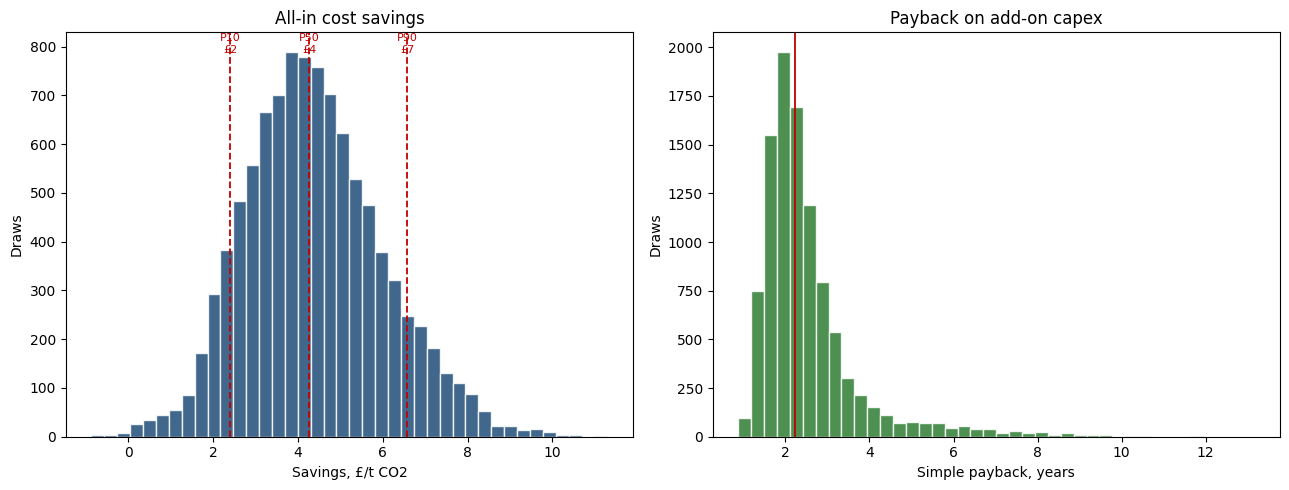

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(savings_t, bins=40, color="#1F4E78", edgecolor="white", alpha=0.85)
for val, label in [(p10,"P10"),(p50,"P50"),(p90,"P90")]:
    axes[0].axvline(val, color="#C00000", linestyle="--", linewidth=1.3)
    axes[0].text(val, axes[0].get_ylim()[1]*0.95, f"{label}\n£{val:.0f}", ha="center", fontsize=8, color="#C00000")
axes[0].set_xlabel("Savings, £/t CO2"); axes[0].set_ylabel("Draws"); axes[0].set_title("All-in cost savings")

finite_payback = payback[np.isfinite(payback)]
axes[1].hist(finite_payback, bins=40, color="#2E7D32", edgecolor="white", alpha=0.85)
axes[1].axvline(np.median(finite_payback), color="#C00000", linestyle="-", linewidth=1.3)
axes[1].set_xlabel("Simple payback, years"); axes[1].set_ylabel("Draws"); axes[1].set_title("Payback on add-on capex")

plt.tight_layout()
plt.savefig("hope_amine_optimization_distribution.png", dpi=150)
plt.show()


## 8. Next steps

- **Resolved this pass:** De-SOx opex (both the protection cost P and the degradation-risk cost D) is
  now coupled to a single, sourced inlet-SOx driver (Hope's 2017 EA Decision Document), replacing two
  previously-independent, unsourced placeholders. D > P by construction across Hope's entire realistic
  SOx range (9-61x above the 10ppmv Chapel threshold) — the "De-SOx could be a wash" risk is physically
  excluded, not just unlikely.
- **Still open — De-SOx capex** (`desox_capex_tpa`, Uniform £10-25/tpa): this remains the old, unresolved
  placeholder. Real CEMCAP DCC-train equipment data (column + cooler + circulating pump, ~€3.9M direct
  cost at a comparable-scale reference plant, ~€4.6-5M scaled to Hope) was investigated as a candidate
  replacement, but whether it represents an incremental add-on or is already embedded in the £399.6M
  baseline amine plant capex was not resolved. This is the next highest-value item.
- **Still open — how much has Hope's SOx drifted since 2017:** the EA decision document is the best
  source found, but it's ~9 years old. The "shale reserves depleting by 2025" risk flagged separately
  means today's actual figure could sit anywhere in the modeled PERT(400,700,1760) range. A current
  stack SOx reading (or a newer EA compliance report) would tighten this more than any further Monte
  Carlo refinement.
- Specific heat consumption remains the dominant driver of WHR-side uncertainty (kiln MWth, hence
  available waste heat) — Breedon's real kiln heat-balance data would resolve this directly.
- The oxy-fuel + WHR framework from `Peak_Cluster_Monte_Carlo.ipynb` remains a live benchmark for a
  genuinely different site (modern precalciner kiln), not for Hope.